# General Insurance Corporation of India: Breakdown-Cover Concept Survey
**Case:** Statistical tools for financial decision making (M. Thenmozhi). n = 60 telephone respondents (30 current General Insurance customers, 30 from random-digit dialing).

**How to use:** *Runtime → Run all* on Google Colab. The survey data is embedded in the notebook, so no upload is needed. Only standard libraries are used (pandas, numpy, scipy, statsmodels, seaborn, scikit-learn), and all of them come pre-installed on Colab.

**Notes on method (please read):**
* The data was checked against the PDF table: all 60 rows match.
* The Excel sheet has a pre-computed column `Concept_code` that is 1 for ratings **3, 4, 5**. Question 9 defines "high interest" as **4 or 5**, so this notebook builds its own flag (`hi`) and does **not** use `Concept_code`.
* The rating is a 5-point ordinal scale and n is small, so for most questions I report a parametric test *and* a non-parametric check. Where they disagree, I say so.
* "Significant" means p < 0.05. With n = 60 and many tests, treat borderline results cautiously.

In [1]:
import warnings, io
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.contingency_tables import StratifiedTable
from statsmodels.miscmodels.ordinal_model import OrderedModel
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

In [2]:
DATA = """id,rating,supplier,age,marital,cars,car_age,trips
1,4,G,42,M,1,0.5,3
2,3,G,39,M,1,1.5,1
3,5,G,47,M,1,1.0,4
4,2,G,24,S,3,1.0,2
5,4,G,43,M,2,1.5,4
6,5,G,62,M,1,0.5,6
7,1,G,27,M,1,2.0,3
8,5,G,55,M,2,0.5,4
9,4,G,42,S,1,2.0,2
10,3,G,36,S,1,2.0,2
11,4,G,39,M,3,1.5,5
12,2,G,24,S,4,2.0,0
13,5,G,58,M,1,2.0,6
14,4,G,43,M,1,0.4,2
15,1,G,23,S,2,2.5,0
16,5,G,59,M,1,0.5,7
17,4,G,43,M,3,1.5,3
18,3,G,36,S,1,2.0,0
19,3,G,47,M,1,2.0,1
20,4,G,42,M,1,1.5,4
21,4,G,47,M,4,1.5,4
22,4,G,38,M,2,1.0,3
23,5,G,37,M,2,0.8,8
24,3,G,39,S,1,2.0,0
25,4,G,51,M,1,1.0,2
26,4,G,47,M,2,1.5,1
27,5,G,51,M,1,2.0,6
28,1,G,30,S,1,2.0,0
29,1,G,28,S,2,4.5,2
30,3,G,42,M,2,3.5,1
31,2,O,32,M,3,3.0,0
32,4,O,29,M,1,2.0,3
33,2,O,32,M,1,1.0,0
34,1,O,37,M,1,1.0,0
35,3,O,24,S,4,2.5,1
36,2,O,41,M,1,2.0,3
37,3,O,23,M,1,2.0,0
38,1,O,34,M,5,3.0,1
39,2,O,38,M,2,2.0,0
40,4,O,47,M,2,1.0,5
41,5,O,24,M,1,0.5,0
42,3,O,32,M,1,1.5,0
43,1,O,22,S,1,3.0,1
44,2,O,27,S,1,2.5,0
45,2,O,29,M,3,2.5,0
46,4,O,43,M,2,1.0,2
47,5,O,48,S,1,0.5,3
48,3,O,36,M,1,1.5,0
49,4,O,42,M,3,1.5,2
50,2,O,26,S,2,2.0,2
51,2,O,29,S,1,2.5,1
52,1,O,23,S,1,3.0,0
53,3,O,34,M,1,1.5,0
54,4,O,37,S,1,1.5,2
55,2,O,24,S,2,3.0,0
56,3,O,32,M,2,2.0,1
57,5,O,44,M,1,0.5,7
58,1,O,28,M,1,2.5,0
59,1,O,22,S,2,3.0,1
60,2,O,26,S,1,2.0,1"""
df = pd.read_csv(io.StringIO(DATA))

# --- Optional: to use the original Excel file instead, upload it in Colab and uncomment ---
# from google.colab import files; files.upload()
# raw = pd.read_excel('Insurance_case_data.xlsx').iloc[:, :8]
# raw.columns = ['id','rating','supplier','age','marital','cars','car_age','trips']; df = raw

df['G']  = (df.supplier == 'G').astype(int)            # 1 = current General Insurance customer
df['M']  = (df.marital  == 'M').astype(int)            # 1 = married
df['hi'] = (df.rating >= 4).astype(int)                # high interest = rating 4 or 5 (as in Q9)
df['age_band'] = pd.cut(df.age, [0, 30, 39, 100], labels=['<=30', '31-39', '40+'])   # same cut-offs as the Excel 'age code'
df['group'] = df.supplier.map({'G':'GenIns','O':'Other'}) + '-' + df.marital.map({'M':'Married','S':'Single'})
print(df.shape, '| missing values:', int(df.isna().sum().sum()))
df.head()

(60, 13) | missing values: 0


,id,rating,supplier,age,marital,cars,car_age,trips,G,M,hi,age_band,group
0,1,4,G,42,M,1,0.5,3,1,1,1,40+,GenIns-Married
1,2,3,G,39,M,1,1.5,1,1,1,0,31-39,GenIns-Married
2,3,5,G,47,M,1,1.0,4,1,1,1,40+,GenIns-Married
3,4,2,G,24,S,3,1.0,2,1,0,0,<=30,GenIns-Single
4,5,4,G,43,M,2,1.5,4,1,1,1,40+,GenIns-Married


In [3]:
print(df[['rating','age','trips','cars','car_age']].describe().round(2))
print('\nRating distribution (counts):'); print(df.rating.value_counts().sort_index().to_string())
print('\nHigh interest (4-5):', df.hi.sum(), 'of', len(df), f'({df.hi.mean():.0%})')

       rating    age  trips   cars  car_age
count   60.00  60.00  60.00  60.00    60.00
mean     3.07  36.77   2.03   1.67     1.76
std      1.35  10.15   2.12   0.97     0.86
min      1.00  22.00   0.00   1.00     0.40
25%      2.00  28.00   0.00   1.00     1.00
50%      3.00  37.00   1.50   1.00     2.00
75%      4.00  43.00   3.00   2.00     2.00
max      5.00  62.00   8.00   5.00     4.50

Rating distribution (counts):
rating
1    10
2    12
3    12
4    16
5    10

High interest (4-5): 26 of 60 (43%)


---
## Q1. How is interest in the concept related to (a) current supplier, (b) age, (c) number of trips?
### 1(a) Current General Insurance customer vs not

          count  mean  median   std
supplier                           
G            30  3.50     4.0  1.31
O            30  2.63     2.0  1.27

Welch t-test      : TtestResult(statistic=np.float64(2.602693835984186), pvalue=np.float64(0.011724805424244486), df=np.float64(57.96002773889358))
Mann-Whitney U    : MannwhitneyuResult(statistic=np.float64(617.0), pvalue=np.float64(0.011817070935750356))
Cohen's d         : 0.67

High-interest (4-5) by supplier:
hi         0   1
supplier        
G         12  18
O         22   8
Share high-interest -> G: 60%, Other: 27%
Fisher exact      : SignificanceResult(statistic=np.float64(0.24242424242424243), pvalue=np.float64(0.018243850221470598))


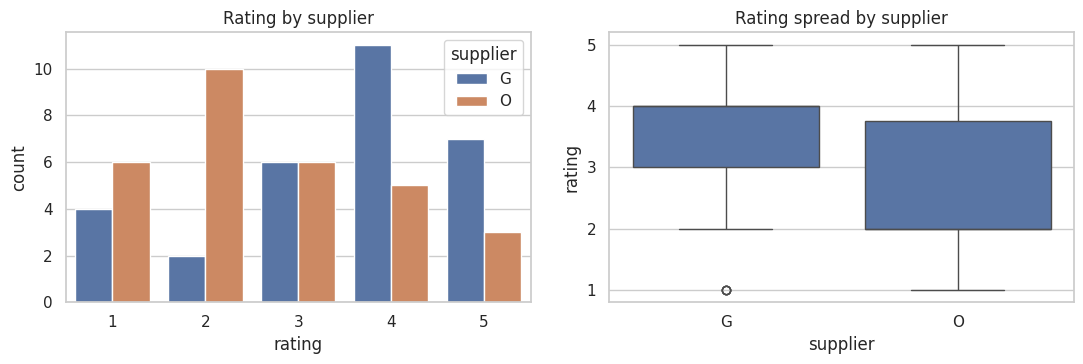

In [4]:
print(df.groupby('supplier').rating.agg(['count','mean','median','std']).round(2))
g, o = df[df.G==1].rating, df[df.G==0].rating
print('\nWelch t-test      :', stats.ttest_ind(g, o, equal_var=False))
print('Mann-Whitney U    :', stats.mannwhitneyu(g, o, alternative='two-sided'))
d_ = (g.mean()-o.mean())/np.sqrt((g.var()+o.var())/2); print(f"Cohen's d         : {d_:.2f}")
ct = pd.crosstab(df.supplier, df.hi); print('\nHigh-interest (4-5) by supplier:'); print(ct)
print('Share high-interest -> G: %.0f%%, Other: %.0f%%' % (100*ct.loc['G',1]/ct.loc['G'].sum(), 100*ct.loc['O',1]/ct.loc['O'].sum()))
print('Fisher exact      :', stats.fisher_exact(ct))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.countplot(data=df, x='rating', hue='supplier', ax=ax[0]); ax[0].set_title('Rating by supplier')
sns.boxplot(data=df, x='supplier', y='rating', ax=ax[1]); ax[1].set_title('Rating spread by supplier'); plt.tight_layout(); plt.show()

**Reading (1a):** General Insurance customers rate the concept higher (mean ≈ 3.50 vs 2.63; Welch p ≈ 0.012, Mann-Whitney p ≈ 0.012, Cohen's d ≈ 0.7, a medium-to-large effect). 60% of GI customers give 4-5 versus 27% of other-company respondents (Fisher p ≈ 0.018). **Caution:** this is a raw association. GI customers are also older (mean 41 vs 32) and take more trips, so supplier may be standing in for age. Q6, Q7 and Q8 test this.

### 1(b) Age

Pearson : PearsonRResult(statistic=np.float64(0.7387538159691998), pvalue=np.float64(1.604621210006789e-11))
Spearman: SignificanceResult(statistic=np.float64(0.7496493538764952), pvalue=np.float64(5.51458772638336e-12))
           n  mean_rating  pct_hi  avg_trips
age_band                                    
<=30      20         1.95    0.10       0.85
31-39     17         2.88    0.24       1.35
40+       23         4.17    0.87       3.57
Kruskal-Wallis across age bands: KruskalResult(statistic=np.float64(29.639532834807337), pvalue=np.float64(3.663171248366339e-07))


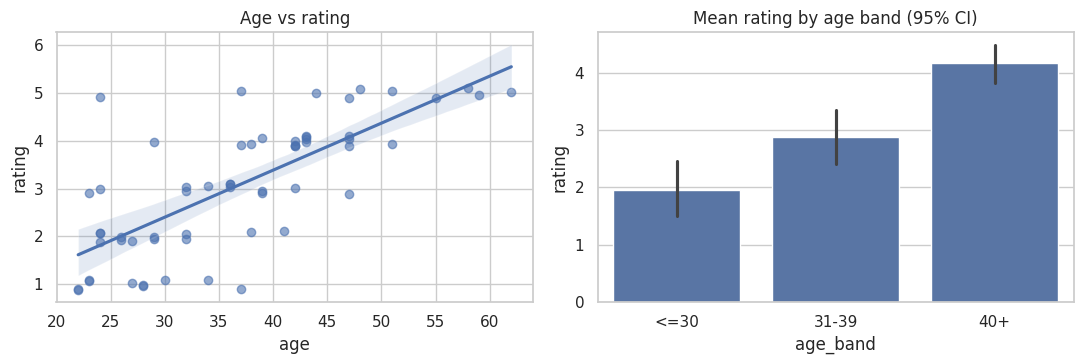

In [5]:
print('Pearson :', stats.pearsonr(df.age, df.rating)); print('Spearman:', stats.spearmanr(df.age, df.rating))
print(df.groupby('age_band', observed=True).agg(n=('rating','size'), mean_rating=('rating','mean'), pct_hi=('hi','mean'), avg_trips=('trips','mean')).round(2))
print('Kruskal-Wallis across age bands:', stats.kruskal(*[s.rating for _, s in df.groupby('age_band', observed=True)]))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.regplot(data=df, x='age', y='rating', x_jitter=0, y_jitter=.12, ax=ax[0], scatter_kws={'alpha':.6}); ax[0].set_title('Age vs rating')
sns.barplot(data=df, x='age_band', y='rating', ax=ax[1], errorbar=('ci',95)); ax[1].set_title('Mean rating by age band (95% CI)'); plt.tight_layout(); plt.show()

**Reading (1b):** Age is the strongest single correlate of interest (Spearman ρ ≈ 0.75, p < 0.001). Mean rating rises from ≈ 1.95 (≤ 30) to ≈ 2.88 (31-39) to ≈ 4.17 (40+); 87% of the 40+ group rate 4-5 versus 10% of the ≤ 30 group.

### 1(c) Number of automobile trips

Pearson : PearsonRResult(statistic=np.float64(0.6845372341066017), pvalue=np.float64(1.6312683425523036e-09))
Spearman: SignificanceResult(statistic=np.float64(0.679362170722471), pvalue=np.float64(2.4087177147296763e-09))
            n  mean_rating  pct_hi
trip_band                         
0          19         2.21    0.05
1-2        21         2.76    0.33
3+         20         4.20    0.90


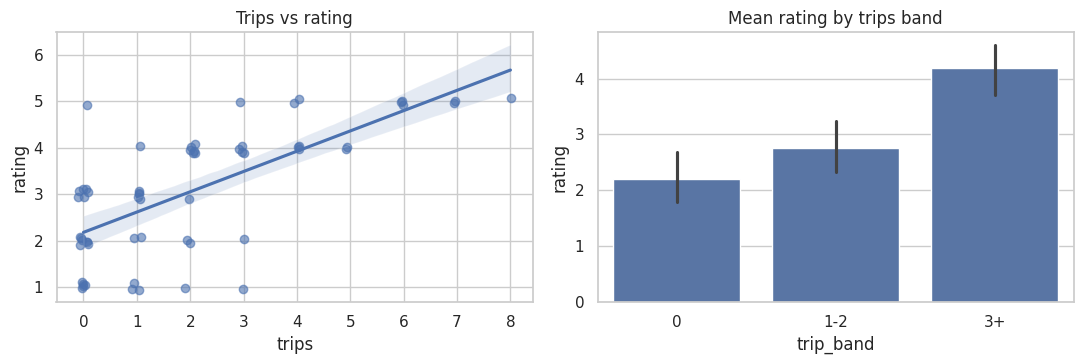

In [6]:
print('Pearson :', stats.pearsonr(df.trips, df.rating)); print('Spearman:', stats.spearmanr(df.trips, df.rating))
df['trip_band'] = pd.cut(df.trips, [-1, 0, 2, 100], labels=['0', '1-2', '3+'])
print(df.groupby('trip_band', observed=True).agg(n=('rating','size'), mean_rating=('rating','mean'), pct_hi=('hi','mean')).round(2))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.regplot(data=df, x='trips', y='rating', y_jitter=.12, x_jitter=.1, ax=ax[0], scatter_kws={'alpha':.6}); ax[0].set_title('Trips vs rating')
sns.barplot(data=df, x='trip_band', y='rating', ax=ax[1], errorbar=('ci',95)); ax[1].set_title('Mean rating by trips band'); plt.tight_layout(); plt.show()

**Reading (1c):** Trips and interest are strongly positively related (Spearman ρ ≈ 0.68, p < 0.001). Respondents with 3+ trips average ≈ 4.2 and 90% rate 4-5; those with no trips average ≈ 2.2 and only 5% rate 4-5. This is intuitive: the product pays out on long trips, so people who take them value it most.

---
## Q2. Representative age and number of trips: how far can they guide decisions?

        mean  median  mode    std  CV_pct   IQR  skew  ci95_low  ci95_high
age    36.77    37.0  24.0  10.15   27.61  15.0  0.41     34.14      39.39
trips   2.03     1.5   0.0   2.12  104.41   3.0  1.02      1.48       2.58

Respondents with zero trips: 19 of 60


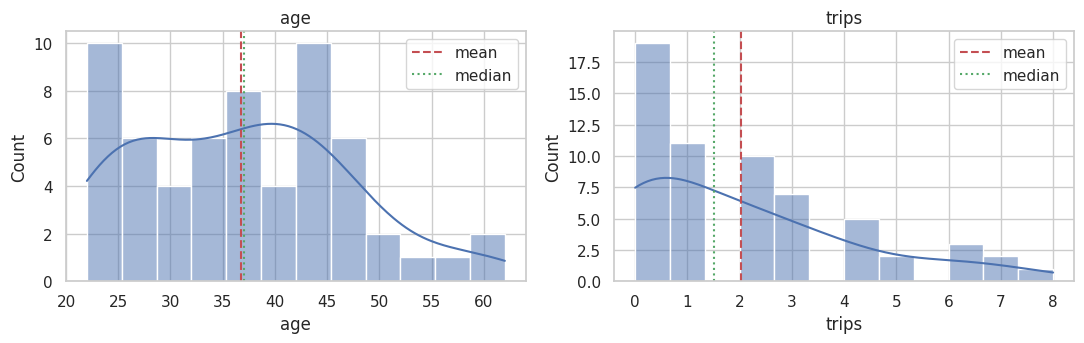

In [7]:
rows = {}
for c in ['age', 'trips']:
    x = df[c]; n = len(x); se = x.std()/np.sqrt(n); ci = stats.t.interval(0.95, n-1, loc=x.mean(), scale=se)
    rows[c] = dict(mean=x.mean(), median=x.median(), mode=x.mode().iloc[0], std=x.std(), CV_pct=100*x.std()/x.mean(),
                   IQR=x.quantile(.75)-x.quantile(.25), skew=stats.skew(x), ci95_low=ci[0], ci95_high=ci[1])
print(pd.DataFrame(rows).T.round(2))
print('\nRespondents with zero trips:', (df.trips==0).sum(), 'of 60')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, c in zip(ax, ['age', 'trips']):
    sns.histplot(df[c], bins=12, kde=True, ax=a); a.axvline(df[c].mean(), color='r', ls='--', label='mean'); a.axvline(df[c].median(), color='g', ls=':', label='median'); a.legend(); a.set_title(c)
plt.tight_layout(); plt.show()

**Reading (Q2):**
* **Age:** mean ≈ 36.8, median 37: roughly symmetric, so ~37 is a fair "typical" age. But the spread is wide (SD ≈ 10, range 22-62).
* **Trips:** mean ≈ 2.0, median 1.5, mode 0; skewed right (skew ≈ 1.0), with 19 of 60 respondents taking **no** long trips. The **median is the better summary** here. The mean is pulled up by a few heavy travellers.
* **Decision value is limited.** Interest in the policy is almost entirely a function of *where in the distribution* a person sits (Q1). A "typical" 37-year-old with 1-2 trips is the *least* informative customer to design for: the interest comes from the 40+ and 3+ trip tails. Segment-level figures are far more useful than averages for this decision.

---
## Q3. Outliers?

age      IQR-rule outlier ids: []  | |z|>3 ids: []
trips    IQR-rule outlier ids: [23]  | |z|>3 ids: []
cars     IQR-rule outlier ids: [12, 21, 35, 38]  | |z|>3 ids: [38]
car_age  IQR-rule outlier ids: [29]  | |z|>3 ids: [29]
rating   IQR-rule outlier ids: []  | |z|>3 ids: []

 id  rating supplier  age marital  cars  car_age  trips
 23       5        G   37       M     2      0.8      8
 29       1        G   28       S     2      4.5      2
 38       1        O   34       M     5      3.0      1


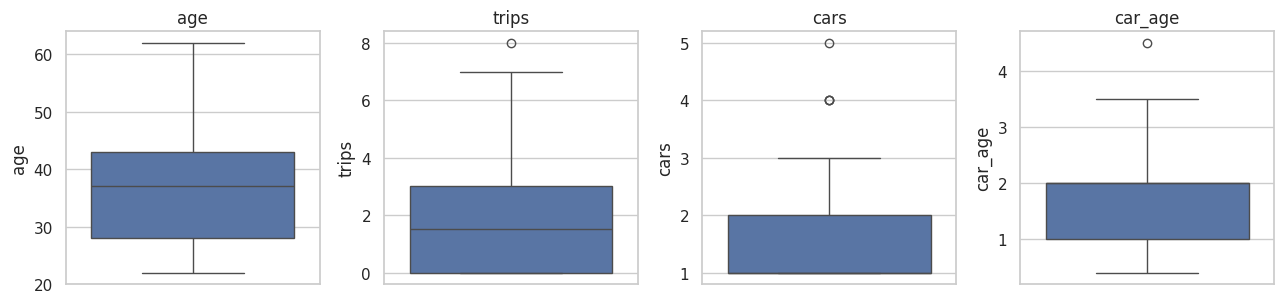

           coef_all  p_all  coef_without_3  p_without_3
Intercept     1.988  0.002           1.763        0.009
age           0.047  0.001           0.051        0.001
trips         0.181  0.005           0.166        0.025
car_age      -0.578  0.000          -0.512        0.002


In [8]:
def outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3-q1
    iqr = df.loc[(s < q1-1.5*i) | (s > q3+1.5*i), 'id'].tolist()
    z = df.loc[np.abs(stats.zscore(s)) > 3, 'id'].tolist()
    return iqr, z
for c in ['age', 'trips', 'cars', 'car_age', 'rating']:
    iqr, z = outliers(df[c]); print(f'{c:8s} IQR-rule outlier ids: {iqr}  | |z|>3 ids: {z}')
print(); print(df.loc[df.id.isin([23, 29, 38]), ['id','rating','supplier','age','marital','cars','car_age','trips']].to_string(index=False))
fig, ax = plt.subplots(1, 4, figsize=(13, 3.2))
for a, c in zip(ax, ['age', 'trips', 'cars', 'car_age']): sns.boxplot(y=df[c], ax=a); a.set_title(c)
plt.tight_layout(); plt.show()

# Robustness: does dropping the flagged respondents change the main model?
f = 'rating ~ age + trips + car_age'
full = smf.ols(f, df).fit(); trim = smf.ols(f, df[~df.id.isin([23, 29, 38])]).fit()
print(pd.DataFrame({'coef_all': full.params, 'p_all': full.pvalues, 'coef_without_3': trim.params, 'p_without_3': trim.pvalues}).round(3))

**Reading (Q3):** Few flagged points, and none look like errors:
* **ID 23:** 8 trips (IQR-rule outlier; z ≈ 2.8, i.e. not extreme). A plausible heavy traveller who rated the concept 5.
* **ID 29:** car age 4.5 years (flagged by both rules; the oldest car in the sample).
* **ID 38:** 5 cars (flagged by z; count variable with a long tail).
* Age and rating have no outliers.

**What to do:** these are genuine, valid responses, not data-entry mistakes, so I **keep them**. Dropping the three records leaves the signs and the significance of all three predictors unchanged (table above), although the trips effect gets somewhat weaker (p ≈ 0.005 → 0.025), so the main conclusions do not depend on these respondents. If an outlier were a clear error, I would correct or remove it. If it were genuine but influential, I would report results with and without it (as done here) or use robust or non-parametric methods.

---
## Q4. Are the variables normally distributed?

variable  Shapiro W      p-value  skew  excess kurtosis verdict at 5%
     age      0.956 3.088393e-02  0.41            -0.51    Not normal
   trips      0.858 5.119392e-06  1.02             0.22    Not normal
    cars      0.716 1.796038e-09  1.50             1.67    Not normal
 car_age      0.942 6.661949e-03  0.50             0.39    Not normal
  rating      0.898 1.099033e-04 -0.12            -1.19    Not normal


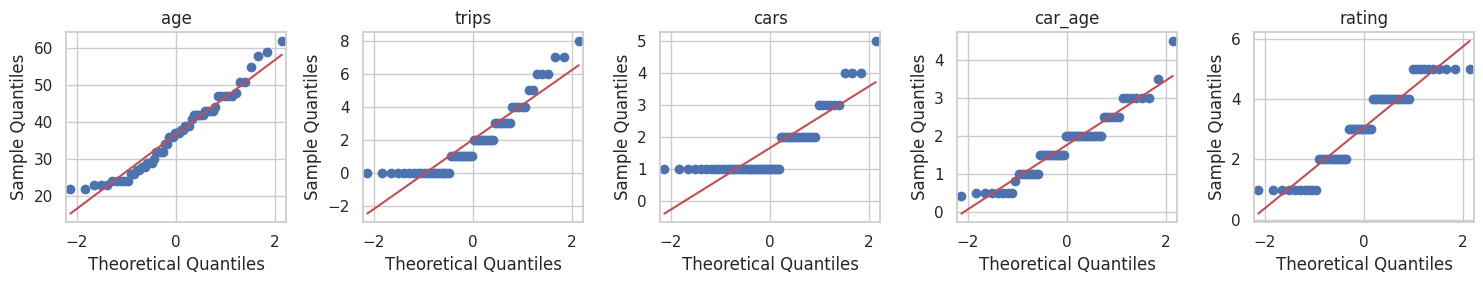

Shapiro on regression residuals: ShapiroResult(statistic=np.float64(0.9779831855323491), pvalue=np.float64(0.34930859305403766))


In [9]:
rows = []
for c in ['age', 'trips', 'cars', 'car_age', 'rating']:
    w, p = stats.shapiro(df[c]); rows.append([c, round(w, 3), p, round(stats.skew(df[c]), 2), round(stats.kurtosis(df[c]), 2), 'Normal' if p > .05 else 'Not normal'])
print(pd.DataFrame(rows, columns=['variable', 'Shapiro W', 'p-value', 'skew', 'excess kurtosis', 'verdict at 5%']).to_string(index=False))
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for a, c in zip(ax, ['age', 'trips', 'cars', 'car_age', 'rating']): sm.qqplot(df[c], line='s', ax=a); a.set_title(c)
plt.tight_layout(); plt.show()
m = smf.ols('rating ~ age + trips + car_age', df).fit(); print('Shapiro on regression residuals:', stats.shapiro(m.resid))

**Reading (Q4):** By Shapiro-Wilk, **none of the five variables is normal** at 5%. Age is only mildly non-normal (p ≈ 0.03); trips (right-skewed), number of cars (heavily skewed, mostly 1) and car age are clearly non-normal, and the rating is a discrete 1-5 scale. This is why the notebook pairs t-tests with Mann-Whitney / Kruskal-Wallis and uses Spearman alongside Pearson. What matters for the regression in Q7 is the normality of the *residuals*, and those pass (p ≈ 0.35).

---
## Q5. Association between concept rating and current insurer

In [10]:
ct = pd.crosstab(df.supplier, df.rating); print(ct)
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f'\nChi-square = {chi2:.2f}, dof = {dof}, p = {p:.4f}; min expected cell count = {exp.min():.1f}')
print("Cramer's V =", round(np.sqrt(chi2/(len(df)*(min(ct.shape)-1))), 2))
ct2 = pd.crosstab(df.supplier, df.hi); print('\nCollapsed (rating 4-5 vs 1-3):'); print(ct2)
print('Chi-square (no correction):', stats.chi2_contingency(ct2, correction=False)[:3], '| Fisher:', stats.fisher_exact(ct2))

rating    1   2  3   4  5
supplier                 
G         4   2  6  11  7
O         6  10  6   5  3

Chi-square = 9.58, dof = 4, p = 0.0481; min expected cell count = 5.0
Cramer's V = 0.4

Collapsed (rating 4-5 vs 1-3):
hi         0   1
supplier        
G         12  18
O         22   8
Chi-square (no correction): (np.float64(6.787330316742082), np.float64(0.009180710329776815), 1) | Fisher: SignificanceResult(statistic=np.float64(0.24242424242424243), pvalue=np.float64(0.018243850221470598))


**Reading (Q5):** Yes, there is a statistically significant association (χ² = 9.58, 4 df, p ≈ 0.048; Cramér's V ≈ 0.40, a moderate association). Expected cell counts are ≥ 5, so the test is valid, but p is close to the 0.05 line. Collapsing to high vs not-high gives a clearer result (Fisher p ≈ 0.018). Shape of the pattern: GI customers cluster at 4-5, others at 1-2.

---
## Q6. Is the association different across age groups?

rating             1  2  3  4  5
age_band supplier               
<=30     G         4  2  0  0  0
         O         4  6  2  1  1
31-39    G         0  0  4  2  1
         O         2  3  4  1  0
40+      G         0  0  2  9  6
         O         0  1  0  3  2

Mean rating, supplier x age band:
          mean       count    
supplier     G     O     G   O
age_band                      
<=30      1.33  2.21     6  14
31-39     3.57  2.40     7  10
40+       4.24  4.00    17   6

Within each age band, G vs Other:
  <=30   mean G=1.33, Other=2.21 | Mann-Whitney p=0.085 | Fisher p (4-5 share)=1.000
  31-39  mean G=3.57, Other=2.40 | Mann-Whitney p=0.026 | Fisher p (4-5 share)=0.250
  40+    mean G=4.24, Other=4.00 | Mann-Whitney p=0.816 | Fisher p (4-5 share)=1.000

Cochran-Mantel-Haenszel (supplier effect controlling for age band): p = 0.458 | pooled OR = 0.57
Breslow-Day (is the effect different across bands?): p = 0.251

Two-way ANOVA (rating ~ supplier x age band):
                 

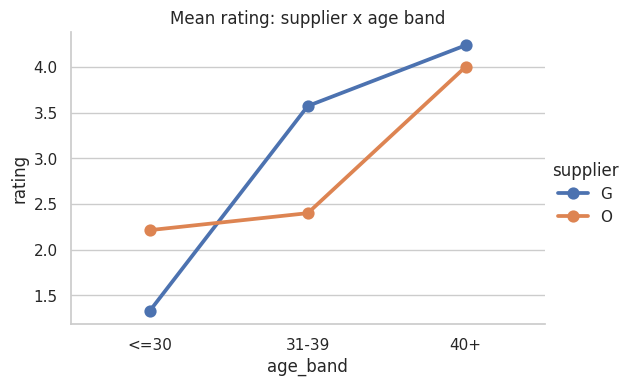

In [11]:
print(pd.crosstab([df.age_band, df.supplier], df.rating))
print('\nMean rating, supplier x age band:'); print(df.pivot_table(index='age_band', columns='supplier', values='rating', aggfunc=['mean','count'], observed=True).round(2))
print('\nWithin each age band, G vs Other:')
tabs = []
for b, s in df.groupby('age_band', observed=True):
    t = pd.crosstab(s.supplier, s.hi).reindex(index=['G','O'], columns=[0,1], fill_value=0); tabs.append(t.values)
    print(f'  {b:6s} mean G={s[s.G==1].rating.mean():.2f}, Other={s[s.G==0].rating.mean():.2f} | Mann-Whitney p={stats.mannwhitneyu(s[s.G==1].rating, s[s.G==0].rating).pvalue:.3f} | Fisher p (4-5 share)={stats.fisher_exact(t)[1]:.3f}')
st = StratifiedTable(tabs)
print('\nCochran-Mantel-Haenszel (supplier effect controlling for age band): p =', round(st.test_null_odds().pvalue, 3), '| pooled OR =', round(st.oddsratio_pooled, 2))
print('Breslow-Day (is the effect different across bands?): p =', round(st.test_equal_odds().pvalue, 3))
a = smf.ols('rating ~ C(supplier) * C(age_band)', df).fit(); print('\nTwo-way ANOVA (rating ~ supplier x age band):'); print(sm.stats.anova_lm(a, typ=2).round(4))
print('\nRating vs age band overall: chi-square p =', round(stats.chi2_contingency(pd.crosstab(df.age_band, df.rating))[1], 6))
sns.catplot(data=df, x='age_band', y='rating', hue='supplier', kind='point', height=3.8, aspect=1.5, errorbar=None); plt.title('Mean rating: supplier x age band'); plt.show()

**Reading (Q6):** The supplier gap is **not a stable, uniform effect; it depends on age**, and most of the raw gap comes from age itself:
* Rating rises sharply with age (overall age band vs rating chi-square p < 0.001; two-way ANOVA age-band p < 0.001).
* Controlling for age band, the **supplier main effect disappears** (ANOVA p ≈ 0.51; Mantel-Haenszel on the 4-5 share, p ≈ 0.46).
* But the **supplier × age-band interaction is significant** (ANOVA p ≈ 0.008). Mean ratings, GI vs other: ≤ 30: 1.33 vs 2.21 (only 6 GI customers; p ≈ 0.09); 31-39: 3.57 vs 2.40 (Mann-Whitney p ≈ 0.026, uncorrected for 3 comparisons); 40+: 4.24 vs 4.00 (no difference). So the answer to "is the association different by age group?" is **yes in pattern**: GI customers are more enthusiastic only in the middle band, and the oldest respondents like the concept regardless of insurer.
* Caveat: cells hold only 6-17 respondents, so these band-level contrasts are fragile (one test is borderline and unadjusted for multiple comparisons). The Breslow-Day test on the binary 4-5 flag does not detect heterogeneity (p ≈ 0.25), which is consistent with low power rather than proof of uniformity.

---
## Q7. Which variables influence the rating?

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9369      0.648      2.989      0.004       0.637       3.237
age            0.0494      0.016      3.092      0.003       0.017       0.082
trips          0.1825      0.065      2.825      0.007       0.053       0.312
cars           0.0187      0.109      0.172      0.864      -0.199       0.237
car_age       -0.5833      0.148     -3.941      0.000      -0.880      -0.286
G             -0.0705      0.232     -0.303      0.763      -0.537       0.396
M             -0.0412      0.259     -0.159      0.874      -0.561       0.479
R2 = 0.709, adj R2 = 0.676, F-test p = 1.28e-12

VIF (multicollinearity): {'age': np.float64(2.63), 'trips': np.float64(1.88), 'cars': np.float64(1.1), 'car_age': np.float64(1.6), 'G': np.float64(1.37), 'M': np.float64(1.51)}

=== Reduced model (significant predictors only) ===
          

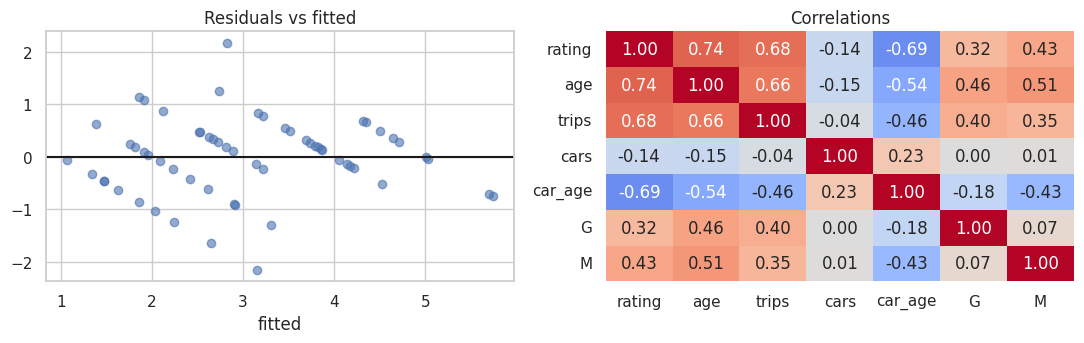

In [12]:
full = smf.ols('rating ~ age + trips + cars + car_age + G + M', df).fit()
print(full.summary().tables[1]); print(f'R2 = {full.rsquared:.3f}, adj R2 = {full.rsquared_adj:.3f}, F-test p = {full.f_pvalue:.2e}')
X = sm.add_constant(df[['age','trips','cars','car_age','G','M']])
print('\nVIF (multicollinearity):', {c: round(variance_inflation_factor(X.values, i), 2) for i, c in enumerate(X.columns) if c != 'const'})

red = smf.ols('rating ~ age + trips + car_age', df).fit()
print('\n=== Reduced model (significant predictors only) ==='); print(red.summary().tables[1]); print(f'R2 = {red.rsquared:.3f}, adj R2 = {red.rsquared_adj:.3f}')
print('Joint F-test that cars, G, M add nothing:', full.compare_f_test(red)[:2])
z = df[['rating','age','trips','car_age']].apply(stats.zscore); sb = smf.ols('rating ~ age + trips + car_age', z).fit().params.drop('Intercept')
print('\nStandardised betas (relative importance):'); print(sb.round(2).to_string())
print('\nResidual Shapiro p =', round(stats.shapiro(red.resid).pvalue, 3), '| Durbin-Watson =', round(sm.stats.durbin_watson(red.resid), 2))

o = OrderedModel(df.rating, df[['age','trips','car_age']], distr='logit').fit(method='bfgs', disp=0)
print('\n=== Robustness: ordinal logit (respects 1-5 ordering) ==='); print(o.summary().tables[1])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(red.fittedvalues, red.resid, alpha=.6); ax[0].axhline(0, color='k'); ax[0].set_title('Residuals vs fitted'); ax[0].set_xlabel('fitted')
sns.heatmap(df[['rating','age','trips','cars','car_age','G','M']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[1], cbar=False); ax[1].set_title('Correlations'); plt.tight_layout(); plt.show()

**Reading (Q7):** The regression is highly significant (R² ≈ 0.71, adj. R² ≈ 0.68, F-test p < 10⁻¹¹) and residuals look well behaved. Three variables matter:

| Variable | Effect on rating | Significance |
|---|---|---|
| **Age** | +≈0.05 per year (≈ +0.5 per decade) | p ≈ 0.001 |
| **Number of trips** | +≈0.18 per extra trip | p ≈ 0.005 |
| **Average age of car** | **−≈0.58 per extra year** | p < 0.001 |

Number of cars, current insurer and marital status are **not significant once these three are in the model** (p = 0.86, 0.76, 0.87), and dropping them costs essentially no fit (R² 0.709 → 0.708). In standardised terms the three predictors are of similar importance (car age −0.37, age +0.35, trips +0.28). So the raw supplier and marital effects seen in Q1/Q8 are largely proxies for age, trips and car age. The ordinal logit gives the same three significant predictors, so the finding does not hinge on treating the 1-5 rating as numeric.

**Two cautions.** (1) The *car-age* effect is the opposite of what a "breakdown risk" story would predict, since older cars break down more, yet owners of older cars are *less* interested. The data cannot tell us why (price sensitivity, perceived value of Rs. 20,000 cover on a low-value car, and income are all untested), so I would not build the marketing story on it without further research. (2) These are associations from 60 people, not causal effects. Age, trips and car age are correlated with each other (|r| 0.46-0.66), which makes individual coefficients less precise than the overall fit.

---
## Q8. Four groups: GI-single, GI-married, Other-single, Other-married

                 n  mean    sd  pct_hi    age  trips  car_age
group                                                        
GenIns-Married  21  4.05  0.97    0.81  45.67   3.71     1.34
GenIns-Single    9  2.22  1.09    0.11  31.33   0.89     2.22
Other-Married   19  2.84  1.26    0.32  34.58   1.26     1.68
Other-Single    11  2.27  1.27    0.18  28.00   1.09     2.32

Levene (equal variances): LeveneResult(statistic=np.float64(0.8395574712643677), pvalue=np.float64(0.477930071963817))
One-way ANOVA           : F_onewayResult(statistic=np.float64(8.800284360058471), pvalue=np.float64(7.127012877794546e-05))
Kruskal-Wallis          : KruskalResult(statistic=np.float64(19.325900584212615), pvalue=np.float64(0.00023409155692516895))

Tukey HSD post-hoc:


        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2    meandiff p-adj   lower   upper  reject
-------------------------------------------------------------------
GenIns-Married GenIns-Single  -1.8254  0.001 -3.0316 -0.6191   True
GenIns-Married Other-Married  -1.2055 0.0082 -2.1641 -0.2469   True
GenIns-Married  Other-Single  -1.7749 0.0006 -2.9018  -0.648   True
 GenIns-Single Other-Married   0.6199  0.542 -0.6053   1.845  False
 GenIns-Single  Other-Single   0.0505 0.9997 -1.3103  1.4113  False
 Other-Married  Other-Single  -0.5694 0.5578 -1.7165  0.5777  False
-------------------------------------------------------------------
Two-way ANOVA (supplier x marital):
                         sum_sq    df        F  PR(>F)
C(supplier)              9.2898   1.0   7.1054  0.0100
C(marital)              18.0315   1.0  13.7916  0.0005
C(supplier):C(marital)   5.2191   1.0   3.9919  0.0506
Residual                73.2161  56.0      NaN     NaN

F-test: 

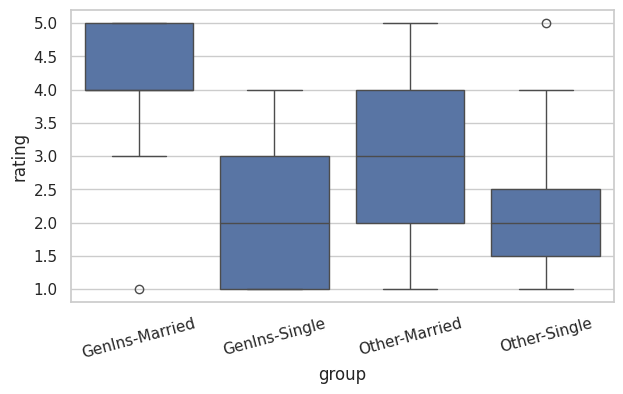

In [13]:
order = ['GenIns-Married', 'GenIns-Single', 'Other-Married', 'Other-Single']
print(df.groupby('group').agg(n=('rating','size'), mean=('rating','mean'), sd=('rating','std'), pct_hi=('hi','mean'), age=('age','mean'), trips=('trips','mean'), car_age=('car_age','mean')).loc[order].round(2))
grp = [df[df.group==g].rating for g in order]
print('\nLevene (equal variances):', stats.levene(*grp))
print('One-way ANOVA           :', stats.f_oneway(*grp))
print('Kruskal-Wallis          :', stats.kruskal(*grp))
print('\nTukey HSD post-hoc:'); print(pairwise_tukeyhsd(df.rating, df.group))
print('Two-way ANOVA (supplier x marital):'); print(sm.stats.anova_lm(smf.ols('rating ~ C(supplier) * C(marital)', df).fit(), typ=2).round(4))
# Do the groups still differ after accounting for age, trips, car age?
base = smf.ols('rating ~ age + trips + car_age', df).fit(); withg = smf.ols('rating ~ age + trips + car_age + C(group)', df).fit()
print('\nF-test: do the 4 groups add anything beyond age, trips, car age? ->', withg.compare_f_test(base)[:2])
plt.figure(figsize=(7, 3.8)); sns.boxplot(data=df, x='group', y='rating', order=order); plt.xticks(rotation=15); plt.show()

**Reading (Q8):** Yes, the four groups differ significantly on rating (ANOVA F ≈ 8.8, p < 0.001; Kruskal-Wallis p < 0.001; variances are comparable, Levene p ≈ 0.48). The post-hoc Tukey test shows a **single standout: married GI customers** (mean ≈ 4.05), who rate higher than each of the other three groups (all ≈ 2.2-2.8, p ≤ 0.008). The other three groups are not distinguishable from one another.

**But** (and this matters for how you use it): after controlling for age, trips and car age, the group differences vanish (the F-test above is not significant). (The supplier × marital interaction in the two-way ANOVA is borderline, p ≈ 0.051.) Married GI customers are simply the oldest, most-travelled group in the sample (mean age ≈ 46, ≈ 3.7 trips), so "married GI customer" is a convenient *label* for the high-interest segment, not an independent driver.

---
## Q9. High interest (4-5) vs lower interest (1-3): what differs?

              n    age  trips  cars  car_age  pct_GI  pct_married
hi                                                               
1-3 (lower)  34  30.76   0.71  1.71     2.24    0.35         0.50
4-5 (high)   26  44.62   3.77  1.62     1.14    0.69         0.88

 variable  mean_high  mean_low      Welch_p  MannWhitney_p
     age      44.62     30.76 1.457782e-08   6.918131e-08
   trips       3.77      0.71 2.728694e-08   9.125096e-09
    cars       1.62      1.71 7.152999e-01   9.597144e-01
 car_age       1.14      2.24 1.689862e-08   2.378218e-07

supplier:
hi         0   1
supplier        
G         12  18
O         22   8
Fisher p = 0.0182

marital:
hi        0   1
marital        
M        17  23
S        17   3
Fisher p = 0.0022

Logistic regression:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.7238      3.039     -0.896      0.370      -8.681       3.

Discriminant analysis, 5-fold CV accuracy: 0.88 (always guessing the majority class = 0.57)


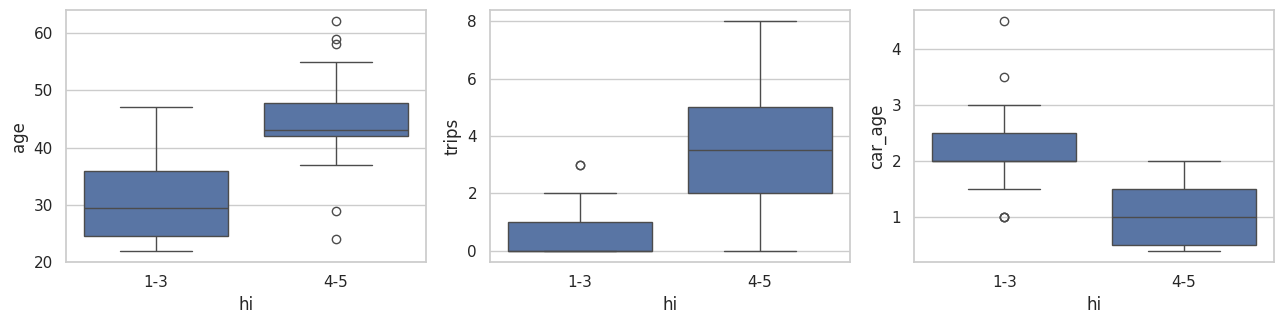

In [14]:
print(df.groupby('hi').agg(n=('id','size'), age=('age','mean'), trips=('trips','mean'), cars=('cars','mean'), car_age=('car_age','mean'), pct_GI=('G','mean'), pct_married=('M','mean')).round(2).rename(index={0:'1-3 (lower)', 1:'4-5 (high)'}))
rows = []
for c in ['age', 'trips', 'cars', 'car_age']:
    a, b = df[df.hi==1][c], df[df.hi==0][c]
    rows.append([c, round(a.mean(),2), round(b.mean(),2), stats.ttest_ind(a, b, equal_var=False).pvalue, stats.mannwhitneyu(a, b).pvalue])
print('\n', pd.DataFrame(rows, columns=['variable','mean_high','mean_low','Welch_p','MannWhitney_p']).to_string(index=False))
for c in ['supplier', 'marital']:
    t = pd.crosstab(df[c], df.hi); print(f'\n{c}:'); print(t); print('Fisher p =', round(stats.fisher_exact(t)[1], 4))

# Multivariate: which characteristics discriminate once considered together?
lg = smf.logit('hi ~ age + trips + car_age', df).fit(disp=0); print('\nLogistic regression:'); print(lg.summary().tables[1])
print('Odds ratios per unit:', np.exp(lg.params).round(2).to_dict())
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score, StratifiedKFold
Xd = df[['age','trips','car_age','cars','G','M']]
print('Discriminant analysis, 5-fold CV accuracy: %.2f (always guessing the majority class = %.2f)' % (cross_val_score(LDA(), Xd, df.hi, cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean(), 1-df.hi.mean()))
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a, c in zip(ax, ['age','trips','car_age']): sns.boxplot(data=df, x='hi', y=c, ax=a); a.set_xticklabels(['1-3','4-5'])
plt.tight_layout(); plt.show()

**Reading (Q9):** The high-interest group (26 of 60, 43%) is clearly different:
* **Older:** mean age ≈ 44.6 vs 30.8.
* **More long trips:** ≈ 3.8 vs 0.7 per year.
* **Newer cars:** ≈ 1.1 vs 2.2 years.
* **More likely to be GI customers** (69% vs 35%) and **married** (88% vs 50%).
* **No difference in number of cars owned** (p ≈ 0.7).

All of the above except cars owned are significant on both parametric and non-parametric tests. In the multivariate view, trips and car age are significant and age is borderline (p ≈ 0.06), and supplier and marital status add nothing. The logistic coefficients are large and unstable because the groups are almost separable on these variables with only 60 observations, so interpret the *direction and rank order*, not the exact odds ratios. The cross-validated discriminant accuracy (~0.88) is encouraging, but it comes from a small sample and untuned model and is likely optimistic.

---
## Q10. Recommendations

In [15]:
df['seg'] = np.where((df.age >= 40) & (df.trips >= 3), 'Age 40+ AND 3+ trips',
            np.where((df.age >= 40) | (df.trips >= 3), 'Age 40+ OR 3+ trips (not both)', 'Neither'))
seg = df.groupby('seg').agg(n=('id','size'), mean_rating=('rating','mean'), pct_high=('hi','mean'), pct_GI=('G','mean'), avg_car_age=('car_age','mean')).round(2)
print(seg.sort_values('pct_high', ascending=False))
print('\nOverall: 4-5 share =', f'{df.hi.mean():.0%}', '| Rating 5 share =', f'{(df.rating==5).mean():.0%}')
print('\nTop-2-box among GI customers: %.0f%% vs Other: %.0f%%' % (100*df[df.G==1].hi.mean(), 100*df[df.G==0].hi.mean()))

                                 n  mean_rating  pct_high  pct_GI  avg_car_age
seg                                                                           
Age 40+ AND 3+ trips            15         4.40      0.93    0.73         1.13
Age 40+ OR 3+ trips (not both)  13         3.69      0.77    0.77         1.55
Neither                         32         2.19      0.06    0.28         2.14

Overall: 4-5 share = 43% | Rating 5 share = 17%

Top-2-box among GI customers: 60% vs Other: 27%


### (a) Wisdom of offering the policy
**A targeted, staged launch looks justified; a mass-market launch does not.** Only 43% of respondents rated the concept 4-5 and the average is 3.07 (i.e. lukewarm). Interest is concentrated, not broad: it is high in a recognisable segment and weak elsewhere. A product that excites a clear minority can still be viable, but this survey does **not** show that it would be profitable.

### (b) Target market
* **Primary:** people aged **40+** who take **3+ long trips a year** (15 of the 60 respondents; 93% rate 4-5, average 4.4). Those meeting only one of the two criteria are at 77% high interest. Those meeting neither are at 6% (n = 32). Caveat: I chose these cut-offs after looking at this data, so the true rates in the wider market are likely lower than these numbers suggest, and n = 15 is small. Newer cars also go with higher interest, but see the caution in Q7.
* **Existing GI customers first.** They show higher stated interest (60% vs 27% top-2-box), they are the cheapest to reach through cross-sell, and the supplier gap largely reflects their older profile, so don't expect them to buy *because* they are GI customers. Note that the effect of supplier itself was not significant after controlling for age and trips.
* **De-prioritise:** under-30s (only 10% high interest) and people who take few or no long trips (5% high interest among those with zero trips).

### (c) Trading (marketing) strategy
Position the cover as **peace of mind for frequent long-distance drivers**, not as a general auto add-on; use the existing customer base and renewal touchpoints (trip-heavy, 40+ customers) as the first channel; consider trip-based or short-term riders, since interest tracks travel frequency; and run a pilot before any broad rollout.

### (d) Research to do before introduction
1. **Larger, representative sample** with stratification by age and trip frequency. n = 60 and cells of 6-17 limit what we can conclude.
2. **Stated vs actual behaviour.** A 1-5 interest rating overstates purchase; follow up with purchase-intent, willingness-to-pay and price-sensitivity testing (the Rs. 500 premium vs Rs. 20,000 cap was tested at one price point only).
3. **Economics.** This survey has no claims data. Actuarial work on breakdown frequency, average claim cost, adverse selection (heavy long-distance drivers and older cars are likelier to claim) and moral hazard is needed to confirm Rs. 500 is a profitable price.
4. **Understand the car-age finding.** Why are owners of *newer* cars more interested? Collect car value, income and vehicle type.
5. **Additional variables:** income, city/region, annual kilometres, existing roadside-assistance cover (many car makers and banks already bundle it), and competitor offers.
6. **A pilot or test market** with the target segment to measure real take-up and claims before national launch.

### Limitations to keep in mind
* Small sample, a telephone survey, and one hypothetical price point.
* The two sub-samples were drawn differently (customer list vs random-digit dialing), so some of the "supplier" effect may reflect sampling, not insurer.
* Many correlated predictors: coefficients indicate association, not causation.